In [4]:
import cv2
from matplotlib import pyplot as plt
from Utils.load_utils import load_bsds500
# https://docs.opencv.org/4.x/da/d22/tutorial_py_canny.html
import numpy as np
from scipy import fftpack

bsds_path = "BSR\BSDS500"

data = load_bsds500(bsds_path)



Loading splits:   0%|          | 0/3 [00:00<?, ?it/s, current=train]

BSR\BSDS500\data\groundTruth\train


Loading splits:  33%|███▎      | 1/3 [00:00<00:01,  1.28it/s, current=test] 

BSR\BSDS500\data\groundTruth\test


Loading splits:  67%|██████▋   | 2/3 [00:01<00:00,  1.33it/s, current=val] 

BSR\BSDS500\data\groundTruth\val


Loading splits:  33%|███▎      | 1/3 [00:00<00:00,  5.91it/s, current=test] 

BSR\BSDS500\data\images\train
BSR\BSDS500\data\images\test


Loading splits: 100%|██████████| 3/3 [00:00<00:00,  6.94it/s, current=val] 

BSR\BSDS500\data\images\val


In [ ]:
from metrics import calculate_ODS




AttributeError: 'list' object has no attribute 'astype'

In [9]:
def fourier_denoise(image, percentile=85, K=50):
    # 1. FFT
    F = fftpack.fft2(image)
    F_shift = fftpack.fftshift(F)  # center DC
    M, N = image.shape

    # 2. Magnitude of centered spectrum
    mag = np.abs(F_shift)

    # 3. Optionally zero a small DC block (low frequencies)
    mag[M//2 - K:M//2 + K, N//2 - K:N//2 + K] = 0

    # 4. Keep coefficients below some percentile (remove large peaks)
    thresh = np.percentile(mag, percentile)
    mask = mag < thresh  # True for small coefficients to keep

    # 5. Apply mask in centered domain
    F_shift_filtered = F_shift * mask

    # 6. Unshift and inverse FFT
    F_filtered = fftpack.ifftshift(F_shift_filtered)
    image_filtered = np.real(fftpack.ifft2(F_filtered))

    return image_filtered


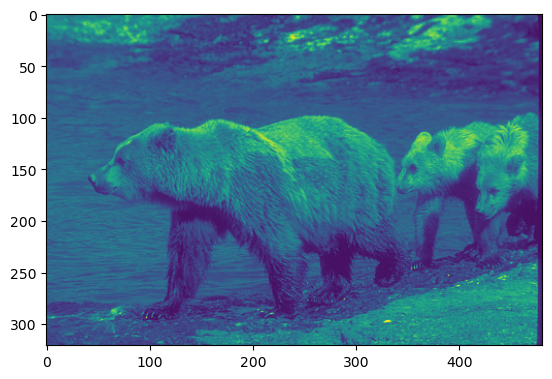

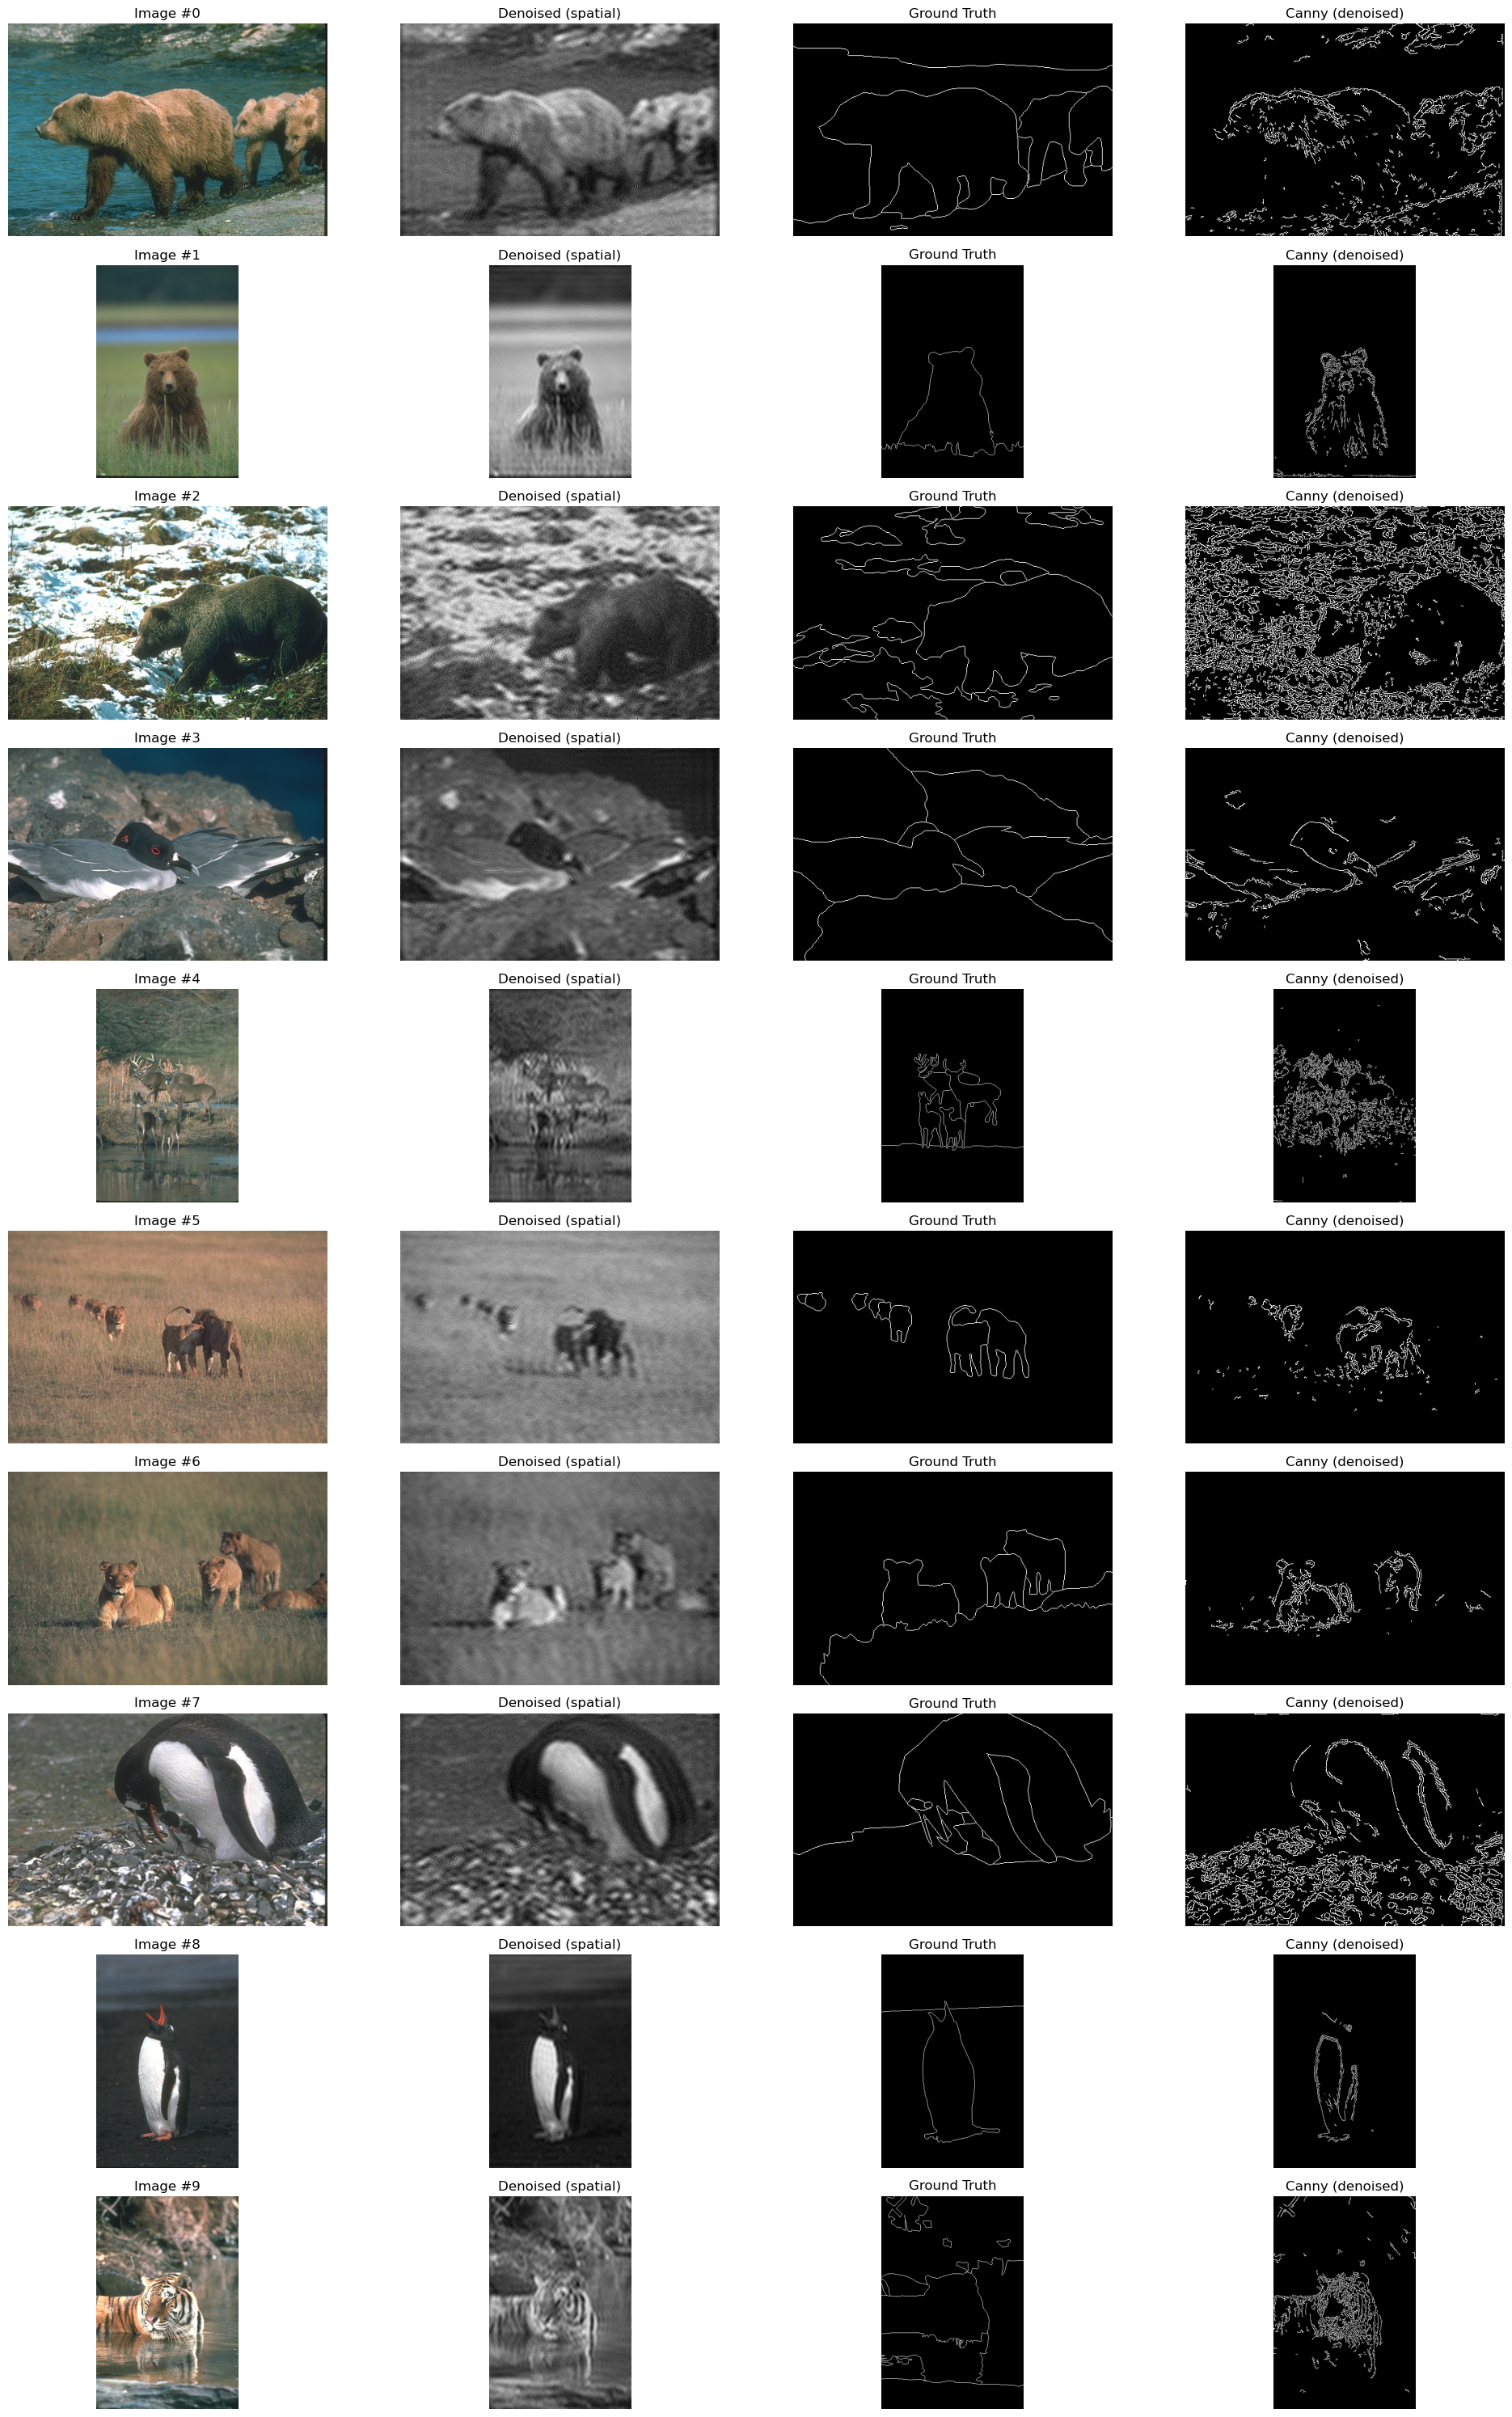

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import fftpack  # make sure this is imported

n_show = 10
fig, axes = plt.subplots(n_show, 4, figsize=(20, 3 * n_show))

for i in range(n_show):
    img = data["images"]["train"][i]
    gt  = data["edges"]["train"][i]

    # handle image format
    if hasattr(img, "cpu"):
        img = img.cpu().numpy()
    if img.ndim == 3 and img.shape[0] in (1, 3):  # CHW -> HWC
        img = np.transpose(img, (1, 2, 0))

    # grayscale for processing
    if img.ndim == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        img_gray = img

    if img_gray.dtype != np.uint8:
        img_gray = np.clip(img_gray, 0, 1)
        img_gray = (img_gray * 255).astype(np.uint8)

    # ----- Fourier magnitude (original) -----
    F_orig = fftpack.fft2(img_gray)
    F_orig_shift = fftpack.fftshift(F_orig)
    mag_orig = np.log1p(np.abs(F_orig_shift))  # log for visualization

    # ----- denoise in Fourier domain -----
    denoised = fourier_denoise(img_gray, percentile=90, K = 30)

    # back to uint8 (for display + Canny)
    denoised = denoised - denoised.min()
    if denoised.max() > 0:
        denoised = denoised / denoised.max()
    denoised = (denoised * 255).astype(np.uint8)

    # ----- Fourier magnitude (after denoising) -----
    F_denoised = fftpack.fft2(denoised)
    F_denoised_shift = fftpack.fftshift(F_denoised)
    mag_denoised = np.log1p(np.abs(F_denoised_shift))

    # Canny on denoised image
    edges = cv2.Canny(denoised, threshold1=100, threshold2=200)

    # ground truth
    if hasattr(gt, "cpu"):
        gt = gt.cpu().numpy()
    gt = np.squeeze(gt)

    # ---- plotting ----
    # 0: original
    axes[i, 0].imshow(img, cmap='gray' if img.ndim == 2 else None)
    axes[i, 0].set_title(f"Image #{i}")
    axes[i, 0].axis("off")

    # 1: denoised (grayscale)
    axes[i, 1].imshow(denoised, cmap="gray")
    axes[i, 1].set_title("Denoised (spatial)")
    axes[i, 1].axis("off")


    # 4: ground truth edges
    axes[i, 2].imshow(gt, cmap="gray")
    axes[i, 2].set_title("Ground Truth")
    axes[i, 2].axis("off")

    # 5: Canny on denoised
    axes[i, 3].imshow(edges, cmap="gray")
    axes[i, 3].set_title("Canny (denoised)")
    axes[i, 3].axis("off")

plt.tight_layout()
plt.show()
